In [1]:
# Import libraries
import os
import requests
import pandas as pd
from PIL import Image
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
import torchvision.models as models
import torchvision.transforms as transforms
import torch
import json
from io import BytesIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, normalize
from sklearn.cluster import DBSCAN
import json
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from IPython.display import display
import matplotlib.pyplot as plt

In [2]:
# Read data
df = pd.read_json('sneakers_sample_19062025.txt', lines=False)

print(df.head())

                                                data  \
0  {'EAN': [], 'size': '44', 'brand': 'ASICS', 'c...   
1  {'EAN': [], 'size': '44', 'brand': 'VANS', 'co...   
2  {'EAN': [], 'size': '44.5', 'brand': 'ADIDAS',...   
3  {'EAN': [], 'size': '42', 'brand': 'NIKE', 'co...   
4  {'EAN': [], 'size': '11/EU 46', 'brand': 'PUMA...   

                      mirakl_product_id             creation_date  \
0  d96975c5-0bea-41f6-a4a8-fdac53f374f3  2024-01-09T12:09:20.568Z   
1  6f302b78-9a86-484e-894f-bb39220931a3  2023-11-09T13:08:33.276Z   
2  70006973-aa9f-4176-9f38-0ba2c5a1b06f  2025-03-29T08:43:47.421Z   
3  6b010b1d-7475-44dc-ad56-502769d2e742  2024-01-04T12:29:59.343Z   
4  cf04d217-bfd6-4743-ae4b-bc98712959ca  2025-02-13T14:31:57.524Z   

                update_date                           product_sku  \
0  2024-11-06T13:03:01.469Z  d96975c5-0bea-41f6-a4a8-fdac53f374f3   
1  2025-02-12T12:21:44.083Z  6f302b78-9a86-484e-894f-bb39220931a3   
2  2025-03-30T21:07:23.464Z  70006973-aa9

In [3]:
df.head()

,data,mirakl_product_id,creation_date,update_date,product_sku,validation,synchronization,catalogs,product_urls,sources,selling_authorization,data_origin
0,"{'EAN': [], 'size': '44', 'brand': 'ASICS', 'c...",d96975c5-0bea-41f6-a4a8-fdac53f374f3,2024-01-09T12:09:20.568Z,2024-11-06T13:03:01.469Z,d96975c5-0bea-41f6-a4a8-fdac53f374f3,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2077', 'provider_sku': '10...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
1,"{'EAN': [], 'size': '44', 'brand': 'VANS', 'co...",6f302b78-9a86-484e-894f-bb39220931a3,2023-11-09T13:08:33.276Z,2025-02-12T12:21:44.083Z,6f302b78-9a86-484e-894f-bb39220931a3,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2002', 'provider_sku': 'VN...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
2,"{'EAN': [], 'size': '44.5', 'brand': 'ADIDAS',...",70006973-aa9f-4176-9f38-0ba2c5a1b06f,2025-03-29T08:43:47.421Z,2025-03-30T21:07:23.464Z,70006973-aa9f-4176-9f38-0ba2c5a1b06f,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2167', 'provider_sku': 'IH...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
3,"{'EAN': [], 'size': '42', 'brand': 'NIKE', 'co...",6b010b1d-7475-44dc-ad56-502769d2e742,2024-01-04T12:29:59.343Z,2024-11-06T13:00:53.470Z,6b010b1d-7475-44dc-ad56-502769d2e742,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '2077', 'provider_sku': 'CT...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
4,"{'EAN': [], 'size': '11/EU 46', 'brand': 'PUMA...",cf04d217-bfd6-4743-ae4b-bc98712959ca,2025-02-13T14:31:57.524Z,2025-03-01T00:03:24.205Z,cf04d217-bfd6-4743-ae4b-bc98712959ca,"{'status': 'VALID', 'validation_errors': []}",{'status': 'SYNCHRONIZED'},[],[],"[{'provider_code': '3390', 'provider_sku': '46...","{'restricted': False, 'authorized_selling_shop...","{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."


### Create separate dataframes

In [8]:
# Load the JSON file
with open('sneakers_sample_19062025.txt', 'r', encoding='utf-8') as f:    # added encoding = utf8 otherwise: decoding error
    raw_data = json.load(f)

# Create separate dataframes
meta_rows = []
data_rows = []
sources_rows = []

# Exclude some fields that are not necessary for our tasks
exclude_fields = {
    'creation_date', 'update_date',
    'validation', 'synchronization',
    'catalogs', 'selling_authorization', "product_urls"
}

for entry in raw_data:
    # Top-level fields
    meta = {
        key: entry[key] for key in entry
        if key not in exclude_fields and key not in ['data', 'sources']
    }
    meta_rows.append(meta)
    
    # Extract nested fields (if they exist)
    if 'data' in entry:
        data_rows.append(entry['data'])
    if 'sources' in entry and isinstance(entry['sources'], list):
        for source in entry['sources']:
            # Optionally, attach product ID to track back
            source['mirakl_product_id'] = entry.get('mirakl_product_id')
            sources_rows.append(source)

# Convert all parts to DataFrames
df_meta = pd.DataFrame(meta_rows)
df_data = pd.json_normalize(data_rows)
df_sources = pd.DataFrame(sources_rows)

# Preview
print("Meta columns:", df_meta.columns.tolist())
print("Data columns:", df_data.columns.tolist())
print("Sources sample:", df_sources.head())

Meta columns: ['mirakl_product_id', 'product_sku', 'data_origin']
Data columns: ['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription']
Sources sample:   provider_code                               provider_sku  \
0          2077        1071A091-101--EUM-18--WHITE / BLACK   
1          2002                   VN0A3MTJT2J1--417--BLACK   
2          2167                                IH6003-44.5   
3          207

In [10]:
df_data

,EAN,size,brand,color,category,returnable,name [el_CY],name [en_GB],updateOnDelta,refinementColor,...,longDescription [el_CY],shoeType,shoeShape,fashionMaterial,shoeWidth,heelHeight,name,heelType,longDescription,shortDescription
0,[],44,ASICS,White / Black,FaMeShSneakers,true,Gel-rocket 11 mens volleyball/indoor shoes,Gel-rocket 11 mens volleyball/indoor shoes,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,[],44,VANS,Black,FaMeShSneakers,true,Mens filmore suede,Mens filmore suede,None,black,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,[],44.5,ADIDAS,NaN,FaMeShSneakers,true,Ih6003,Adidas response,NaN,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[],42,NIKE,White / Black / Volt,FaMeShSneakers,true,React vision worldwide mens,React vision worldwide mens,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,[],11/EU 46,PUMA,Black/white,FaMeShSneakers,true,Puma men's x-ray 3 sd,Puma men's x-ray 3 sd,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,[],37,BUFFALO,White / Silver / Black,FaWoShSneakers,true,Triple hollow sneakers,Triple hollow sneakers,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5819,[],39,ADIDAS ORIGINALS,White,FaWoShSneakers,true,Adidas sambae w,Adidas sambae w,NaN,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5820,[],41,GUESS,White,FaWoShSneakers,true,Elbina sneakers,Elbina sneakers,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5821,[],36.5,NEW BALANCE,Cloud White / Burgundy,FaWoShSneakers,true,327 sportstyle sneakers,327 sportstyle sneakers,None,miscellaneous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df_meta

,mirakl_product_id,product_sku,data_origin
0,d96975c5-0bea-41f6-a4a8-fdac53f374f3,d96975c5-0bea-41f6-a4a8-fdac53f374f3,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
1,6f302b78-9a86-484e-894f-bb39220931a3,6f302b78-9a86-484e-894f-bb39220931a3,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
2,70006973-aa9f-4176-9f38-0ba2c5a1b06f,70006973-aa9f-4176-9f38-0ba2c5a1b06f,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
3,6b010b1d-7475-44dc-ad56-502769d2e742,6b010b1d-7475-44dc-ad56-502769d2e742,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
4,cf04d217-bfd6-4743-ae4b-bc98712959ca,cf04d217-bfd6-4743-ae4b-bc98712959ca,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
...,...,...,...
5818,acdb8093-c93c-49d7-af05-f04cae009f99,acdb8093-c93c-49d7-af05-f04cae009f99,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
5819,e733c608-da84-49f1-a3ae-52a025b1cb3d,e733c608-da84-49f1-a3ae-52a025b1cb3d,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
5820,6d8cf85e-93bd-47ea-8a59-3e43fe4ef732,6d8cf85e-93bd-47ea-8a59-3e43fe4ef732,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."
5821,e2d00db3-27b2-4996-89e2-5c1579af5d39,e2d00db3-27b2-4996-89e2-5c1579af5d39,"{'name [en_GB]': {'origin': 'PROVIDER', 'provi..."


We observe that data_origin column is nested.

In [15]:
# Flatten 'data_origin' column
data_origin_df = pd.json_normalize(df_meta['data_origin'])

# Add prefixes so we know where they came from
data_origin_df = data_origin_df.add_prefix('origin_')

# Drop original nested columns from df_meta
df_meta = df_meta.drop(columns=['data_origin'])

# Merge the flattened parts back
df_meta = pd.concat([df_meta, data_origin_df], axis=1)

In [17]:
df_meta

,mirakl_product_id,product_sku,origin_name [en_GB].origin,origin_name [en_GB].provider_code,origin_name [el_CY].origin,origin_name [el_CY].provider_code,origin_color.origin,origin_color.provider_code,origin_shortDescription [el_CY].origin,origin_shortDescription [el_CY].provider_code,...,origin_heelHeight.origin,origin_heelHeight.provider_code,origin_longDescription.origin,origin_longDescription.provider_code,origin_shortDescription.origin,origin_shortDescription.provider_code,origin_name.origin,origin_name.provider_code,origin_heelType.origin,origin_heelType.provider_code
0,d96975c5-0bea-41f6-a4a8-fdac53f374f3,d96975c5-0bea-41f6-a4a8-fdac53f374f3,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6f302b78-9a86-484e-894f-bb39220931a3,6f302b78-9a86-484e-894f-bb39220931a3,PROVIDER,2002,PROVIDER,2002,PROVIDER,2002,PROVIDER,2002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,70006973-aa9f-4176-9f38-0ba2c5a1b06f,70006973-aa9f-4176-9f38-0ba2c5a1b06f,PROVIDER,2167,PROVIDER,2167,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6b010b1d-7475-44dc-ad56-502769d2e742,6b010b1d-7475-44dc-ad56-502769d2e742,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cf04d217-bfd6-4743-ae4b-bc98712959ca,cf04d217-bfd6-4743-ae4b-bc98712959ca,PROVIDER,3390,PROVIDER,3390,PROVIDER,3390,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,acdb8093-c93c-49d7-af05-f04cae009f99,acdb8093-c93c-49d7-af05-f04cae009f99,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5819,e733c608-da84-49f1-a3ae-52a025b1cb3d,e733c608-da84-49f1-a3ae-52a025b1cb3d,PROVIDER,3429,PROVIDER,3429,PROVIDER,3429,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5820,6d8cf85e-93bd-47ea-8a59-3e43fe4ef732,6d8cf85e-93bd-47ea-8a59-3e43fe4ef732,PROVIDER,2002,PROVIDER,2002,PROVIDER,2002,PROVIDER,2002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5821,e2d00db3-27b2-4996-89e2-5c1579af5d39,e2d00db3-27b2-4996-89e2-5c1579af5d39,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,PROVIDER,2077,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
df_sources

,provider_code,provider_sku,mirakl_product_id
0,2077,1071A091-101--EUM-18--WHITE / BLACK,d96975c5-0bea-41f6-a4a8-fdac53f374f3
1,2002,VN0A3MTJT2J1--417--BLACK,6f302b78-9a86-484e-894f-bb39220931a3
2,2167,IH6003-44.5,70006973-aa9f-4176-9f38-0ba2c5a1b06f
3,2077,CT2927-100--USAM-09--WHITE / BLACK / VOLT,6b010b1d-7475-44dc-ad56-502769d2e742
4,3390,468781-1870785842,cf04d217-bfd6-4743-ae4b-bc98712959ca
...,...,...,...
5818,2077,1636155--EUM-05--WHITE / SILVER / BLACK,acdb8093-c93c-49d7-af05-f04cae009f99
5819,3429,JI1349--1310--WHITE,e733c608-da84-49f1-a3ae-52a025b1cb3d
5820,2002,FLJELBLEA12WHBEI--401--WHITE,6d8cf85e-93bd-47ea-8a59-3e43fe4ef732
5821,2077,WS327-KA--EUM-04--CLOUD WHITE / BURGUNDY,e2d00db3-27b2-4996-89e2-5c1579af5d39


### Task: Match identical products

In [22]:
df_data["jiniusSkuMatchCode"].describe() #all empty

count     5823
unique       1
top         []
freq      5823
Name: jiniusSkuMatchCode, dtype: object

In [24]:
# first inspect features
print(df_data.columns)

Index(['EAN', 'size', 'brand', 'color', 'category', 'returnable',
       'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor',
       'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]',
       'shortDescription [en_GB]', 'mainImage.source',
       'mainImage.original_url', 'secondary_image_1.source',
       'secondary_image_1.original_url', 'secondary_image_2.source',
       'secondary_image_2.original_url', 'secondary_image_3.source',
       'secondary_image_3.original_url', 'longDescription [en_GB]',
       'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial',
       'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription',
       'shortDescription'],
      dtype='object')


In [26]:
#column "name" is empty in almost all rows
df_data["name"].isna().sum()/df_data.shape[0]

0.9958784131890778

In [28]:
#find the only products with non-empty "name" column
df_data[df_data["name"].notna()]

,EAN,size,brand,color,category,returnable,name [el_CY],name [en_GB],updateOnDelta,refinementColor,...,longDescription [el_CY],shoeType,shoeShape,fashionMaterial,shoeWidth,heelHeight,name,heelType,longDescription,shortDescription
1340,[198376576226],43,SKECHERS,Black,FaMeShSneakers,true,Skechers 118317 men shoes,Skechers 118317 men shoes,NaN,black,...,SKECHERS 118317 MEN SHOES / GLIDE STEP,0030,NaN,NaN,medium,NaN,SKECHERS 118317 MEN SHOES / GLIDE STEP,other,SKECHERS 118317 MEN SHOES / GLIDE STEP,SKECHERS 118317 MEN SHOES
1458,[198376147365],41,SKECHERS,Black,FaMeShSneakers,true,210890 bbk skechers men shoes,210890 bbk skechers men shoes,NaN,black,...,210890 BBK SKECHERS MEN SHOES/ SLIP IN,0030,NaN,NaN,medium,NaN,210890 BBK SKECHERS MEN SHOES,other,210890 BBK SKECHERS MEN SHOES/ SLIP IN,210890 BBK SKECHERS MEN SHOES
1805,[196989378503],42,SKECHERS,Grey,FaMeShSneakers,true,Skechers 232700 gry men shoes,Skechers 232700 grymen shoes,NaN,grey,...,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,0020,NaN,NaN,medium,NaN,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,other,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,SKECHERS 232700 GRY MEN SHOES
1853,[196989378527],43,SKECHERS,Grey,FaMeShSneakers,true,Skechers 232700 gry men shoes,Skechers 232700 grymen shoes,NaN,grey,...,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,0020,NaN,NaN,medium,NaN,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,other,SKECHERS 232700 GRY MEN SHOES / ARCH FIT,SKECHERS 232700 GRY MEN SHOES
2443,[198376147419],43,SKECHERS,Black,FaMeShSneakers,true,210890 bbk skechers men shoes,210890 bbk skechers men shoes,NaN,black,...,210890 BBK SKECHERS MEN SHOES/ SLIP IN,0030,NaN,NaN,medium,NaN,210890 BBK SKECHERS MEN SHOES,other,210890 BBK SKECHERS MEN SHOES/ SLIP IN,210890 BBK SKECHERS MEN SHOES
3112,[197976864054],41,SKECHERS,Black,FaWoShSneakers,true,Skechers 150370 bbk women shoes,Skechers 150370 bbk women shoes,None,black,...,SKECHERS 150370 BBK WOMEN SHOES / AIR SOLE,0020,NaN,NaN,medium,NaN,SKECHERS 150370 BBK WOMEN SHOES,other,SKECHERS 150370 BBK WOMEN SHOES / AIR SOLE,SKECHERS 150370 BBK WOMEN SHOES
3455,[196989863429],38,SKECHERS,Black/gold,FaWoShSneakers,true,Skechers 117513 women shoes,Skechers 117513 women shoes,None,black,...,SKECHERS 117513 WOMEN SHOES / MEMORY FOAM,0020,NaN,NaN,medium,NaN,SKECHERS 117513 WOMEN SHOES / BOBS SPORT,other,SKECHERS 117513 WOMEN SHOES / MEMORY FOAM,SKECHERS 117513 WOMEN SHOES
3457,[196989863405],37,SKECHERS,Black/gold,FaWoShSneakers,true,Skechers 117513 women shoes,Skechers 117513 women shoes,None,black,...,SKECHERS 117513 WOMEN SHOES / MEMORY FOAM,0020,NaN,NaN,medium,NaN,SKECHERS 117513 WOMEN SHOES / BOBS SPORT,other,SKECHERS 117513 WOMEN SHOES / MEMORY FOAM,SKECHERS 117513 WOMEN SHOES
3498,[198376755850],39,SKECHERS,Beige/silver,FaWoShSneakers,true,Skechers 150246 ntsl women shoes,Skechers 150246 ntsl women shoes,NaN,beige,...,SKECHERS 150246 NTSL WOMEN SHOES / MEMORY FOAM,0020,NaN,NaN,medium,NaN,SKECHERS 150246 NTSL WOMEN SHOES,other,SKECHERS 150246 NTSL WOMEN SHOES / MEMORY FOAM,SKECHERS 150246 NTSL WOMEN SHOES
3550,[198739014495],41,SKECHERS,Black,FaWoShSneakers,true,Skechers 150562 bklv women shoes,Skechers 150562 bklv women shoes,NaN,black,...,SKECHERS 150562 BKLV WOMEN SHOES / MEMORY FOAM,0020,NaN,NaN,medium,NaN,SKECHERS 150562 BKLV WOMEN SHOES,other,SKECHERS 150562 BKLV WOMEN SHOES / MEMORY FOAM,SKECHERS 150562 BKLV WOMEN SHOES


In [30]:
#check if some name [el_CY] are missing
df_data["name [el_CY]"].isna().sum()

608

In [32]:
#check if some name [en_GB] are missing
df_data["name [en_GB]"].isna().sum() #no missing values

0

Given that "name [el_CY]" has missing values in some rows, while "name [en_GB]" not, it is better not to use the greek name in the following grouping to provide more accurate results. I perform a similar check for English and Greek descriptions.

In [35]:
#check if some shortDescription [el_CY] are missing
df_data["shortDescription [el_CY]"].isna().sum() 

1336

In [37]:
#check if some shortDescription [en_GB] are missing
df_data["shortDescription [en_GB]"].isna().sum() #no missing values

0

Again, some Greek descriptions are missing, while there are no missing English descriptions. So it would be better to use only English.

In [40]:
## assuming identical products have the same brand, color, category, name, shortDescription  /// images will be processed later
#Also, provided that short descriptions are the same, there is no need to include long descriptions

In [42]:
# may adjust these to be more/less strict!
group_keys = [
    #'name',      # must check name field, when i add it, i only get 3 groups :/
    'brand',
    'color',   
    'category',
    'name [en_GB]',
    #'name [el_CY]',
    'shortDescription [en_GB]',
    #'shortDescription [el_CY]'
]


# Group and count occurrences
group_sizes_en = df_data.groupby(group_keys).size().reset_index(name='count')

# Filter groups that occur more than once
duplicates_en = group_sizes_en[group_sizes_en['count'] > 1]

# Get full rows that belong to these duplicate groups
identical_products_en = df_data.merge(duplicates_en[group_keys], on=group_keys, how='inner')

# Assign group IDs
identical_products_en['product_group_id'] = identical_products_en.groupby(group_keys).ngroup()

# Create separate DataFrames for each group
grouped_dict_en = {
    f"group_{group_id}": group_df.drop(columns="product_group_id")
    for group_id, group_df in identical_products_en.groupby("product_group_id")
}

# Preview first 5 groups with only group keys + product_group_id
for group_id, df in list(grouped_dict_en.items())[:5]:
    print(f"\n===== Group: {group_id} =====")
    #print(df[group_keys + ["jiniusSkuMatchCode"]])
    print(df[group_keys])




===== Group: group_0 =====
      brand      color        category name [en_GB]  \
103  ADIDAS  Aluminium  FaMeShSneakers       Ozelle   
104  ADIDAS  Aluminium  FaMeShSneakers       Ozelle   

                              shortDescription [en_GB]  
103  Regular fit<br>Lace closure<br>Textile upper<b...  
104  Regular fit<br>Lace closure<br>Textile upper<b...  

===== Group: group_1 =====
      brand  color        category name [en_GB]  \
199  ADIDAS  Beige  FaMeShSneakers   Adizero sl   
200  ADIDAS  Beige  FaMeShSneakers   Adizero sl   
201  ADIDAS  Beige  FaMeShSneakers   Adizero sl   

                              shortDescription [en_GB]  
199  <br>Lace closure for premium lockdown<br>Part ...  
200  <br>Lace closure for premium lockdown<br>Part ...  
201  <br>Lace closure for premium lockdown<br>Part ...  

===== Group: group_2 =====
      brand  color        category          name [en_GB]  \
741  ADIDAS  Black  FaMeShSneakers  Adidas men alphaedge   
742  ADIDAS  Black  FaMeSh

In [43]:
#### this code adds a column in original df
df_data['product_group_id'] = df_data.groupby(group_keys).ngroup()
df_data

,EAN,size,brand,color,category,returnable,name [el_CY],name [en_GB],updateOnDelta,refinementColor,...,shoeType,shoeShape,fashionMaterial,shoeWidth,heelHeight,name,heelType,longDescription,shortDescription,product_group_id
0,[],44,ASICS,White / Black,FaMeShSneakers,true,Gel-rocket 11 mens volleyball/indoor shoes,Gel-rocket 11 mens volleyball/indoor shoes,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1041.0
1,[],44,VANS,Black,FaMeShSneakers,true,Mens filmore suede,Mens filmore suede,None,black,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4423.0
2,[],44.5,ADIDAS,NaN,FaMeShSneakers,true,Ih6003,Adidas response,NaN,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[],42,NIKE,White / Black / Volt,FaMeShSneakers,true,React vision worldwide mens,React vision worldwide mens,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2839.0
4,[],11/EU 46,PUMA,Black/white,FaMeShSneakers,true,Puma men's x-ray 3 sd,Puma men's x-ray 3 sd,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3168.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5818,[],37,BUFFALO,White / Silver / Black,FaWoShSneakers,true,Triple hollow sneakers,Triple hollow sneakers,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1132.0
5819,[],39,ADIDAS ORIGINALS,White,FaWoShSneakers,true,Adidas sambae w,Adidas sambae w,NaN,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,882.0
5820,[],41,GUESS,White,FaWoShSneakers,true,Elbina sneakers,Elbina sneakers,None,white,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1589.0
5821,[],36.5,NEW BALANCE,Cloud White / Burgundy,FaWoShSneakers,true,327 sportstyle sneakers,327 sportstyle sneakers,None,miscellaneous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2028.0


In [46]:
df_data['product_group_id'].isna().sum()   # why ??????

26

In [48]:
# To find variants - remove color as a group key

import pandas as pd
# may adjust these to be more/less strict!
group_keys = [
    #'name',
    'brand',
    #'color',
    'category',
    'name [en_GB]',
    #'name [el_CY]',
    'shortDescription [en_GB]',
    #'shortDescription [el_CY]'
]


# Group and count occurrences
group_sizes_en = df_data.groupby(group_keys).size().reset_index(name='count')

# Filter groups that occur more than once
duplicates_en = group_sizes_en[group_sizes_en['count'] > 1]

# Get full rows that belong to these duplicate groups
identical_products_en = df_data.merge(duplicates_en[group_keys], on=group_keys, how='inner')

# Assign group IDs
identical_products_en['product_group_id'] = identical_products_en.groupby(group_keys).ngroup()

# Create separate DataFrames for each group
grouped_dict_en = {
    f"group_{group_id}": group_df.drop(columns="product_group_id")
    for group_id, group_df in identical_products_en.groupby("product_group_id")
}

# Preview first 5 groups with only group keys + product_group_id
for group_id, df in list(grouped_dict_en.items())[:5]:
    print(f"\n===== Group: {group_id} =====")
    #print(df[group_keys + ["jiniusSkuMatchCode"]])
    print(df[group_keys])



# this results in groups of identical products in the same/ different colors


===== Group: group_0 =====
      brand        category name [en_GB]  \
560  ADIDAS  FaMeShSneakers  4dfwd 2 men   
561  ADIDAS  FaMeShSneakers  4dfwd 2 men   

                              shortDescription [en_GB]  
560  <br>Lace closure<br>adidas PRIMEKNIT textile u...  
561  <br>Lace closure<br>adidas PRIMEKNIT textile u...  

===== Group: group_1 =====
      brand        category  name [en_GB]  \
457  ADIDAS  FaMeShSneakers  4dfwd 2 mens   
458  ADIDAS  FaMeShSneakers  4dfwd 2 mens   

                              shortDescription [en_GB]  
457  <br>Lace closure<br>adidas PRIMEKNIT textile u...  
458  <br>Lace closure<br>adidas PRIMEKNIT textile u...  

===== Group: group_2 =====
      brand        category name [en_GB] shortDescription [en_GB]
499  ADIDAS  FaMeShSneakers  4dfwd 4 men              4DFWD 4 Men
500  ADIDAS  FaMeShSneakers  4dfwd 4 men              4DFWD 4 Men
501  ADIDAS  FaMeShSneakers  4dfwd 4 men              4DFWD 4 Men
502  ADIDAS  FaMeShSneakers  4dfwd 4 men 

In [50]:
## we also want to process the images 

In [52]:
import pandas as pd

df = pd.read_json("sneakers_sample_19062025.txt", lines=False)
df["image_url"] = df["data"].apply(
    lambda x: x.get("mainImage", {}).get("source") or x.get("mainImage", {}).get("original_url")
)


In [ ]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
import torch
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load JSON
df = pd.read_json('sneakers_sample_19062025.txt', lines=False)

# Extract image URLs
df['image_url'] = df['data'].apply(lambda x: x.get('mainImage', {}).get('original_url', ''))

# Load CLIP model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Function to extract image embedding
def get_embedding(url):
    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert('RGB')
        inputs = processor(images=img, return_tensors="pt").to(device)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
        return image_features.squeeze().cpu().numpy()
    except Exception as e:
        print(f" Failed to load: {url} — {e}")
        return None

# Get image embeddings
print("Extracting embeddings...")
df['embedding'] = df['image_url'].apply(get_embedding)
df = df[df['embedding'].notnull()]  # drop failed images

# Convert to matrix
embeddings = np.vstack(df['embedding'].to_list())

# Compute similarity matrix
similarity = cosine_similarity(embeddings)

# Find top 3 similar images for each
df['top_matches'] = [
    df.iloc[np.argsort(-similarity[i])[1:4]][['image_url', 'data']].to_dict(orient='records')
    for i in range(len(df))
]

# Display variant groups
for i, row in df.iterrows():
    print(f"\n Product: {row['data'].get('name [en_GB]', 'N/A')} ({row['image_url']})")
    for match in row['top_matches']:
        print(f"    Similar: {match['data'].get('name [en_GB]', 'N/A')} - {match['image_url']}")


## Text-Based Title Feature Extraction

In [54]:
# Create title feature from English name
df_data['product_name'] = df_data['name [en_GB]'].fillna('').astype(str)

# TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_data['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# text_sim_matrix[i, j] = similarity between product i and j by title


## Image Feature Extraction

In [61]:
# Load model (no classifier head)
# Loading ResNet50 (pretrained on ImageNet)
# Removing the final classification layer (so we get image features instead of class probabilities)
# Sets the model to evaluation mode (.eval())
device = torch.device("cpu")
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

# Preprocessing
# Resize images to 224x224 and converting to tensor
# Normalizing using ImageNet mean & std (required for pretrained models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Define all fallback image columns, many products have multiple image sources
# The code tries each of these in order until it finds one that works
fallback_cols = [
    'mainImage.original_url',
    'secondary_image_1.original_url',
    'secondary_image_2.original_url',
    'secondary_image_3.original_url'
]

# Initialize storage
image_features = [] # To store embeddings
image_ids = [] # To track product ID for each image
broken_image_rows = [] # Log failed attempts

# Loop through df_data, one product per row
for idx, row in df_data.iterrows():
    success = False
    last_url_attempted = None

    # Try each of the 4 image columns one by one, and skip if the URL is missing or invalid.
    for col in fallback_cols:
        url = row.get(col)
        if not isinstance(url, str) or not url.startswith('http'):
            continue

        last_url_attempted = url

        try:
            response = requests.get(url, timeout=15)

            # Downloading the image with a timeout.
            # Rejecting the result if it's HTML pretending to be an image (Avoid 404 HTML pretending to be a JPG )
            if response.status_code != 200 or b'<html' in response.content[:100].lower():
                raise ValueError("HTML or bad status")

            # Try to open as image, loading the image as RGB.
            # Applying the transform and sends it to the model.
            # Extracting a 2048-d feature vector for each image.
            img = Image.open(BytesIO(response.content)).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                features = model(img_tensor).squeeze().numpy()

            # If image processed successfully, storing its vector and ID.
            # If it failed, moving to the next fallback column.
            image_features.append(features)
            image_ids.append(row.get('mirakl_product_id', f"row_{idx}"))

            print(f"Row {idx}: Loaded image from '{col}'")
            success = True
            break  # Stop after first success

        except Exception as e:
            print(f"Row {idx}: ❌ '{col}' failed: {e}")
            
    # If none of the fallback columns worked, logging the row index and last attempted URL.
    if not success:
        broken_image_rows.append({
            'row_idx': idx,
            'product_id': row.get('mirakl_product_id'),
            'last_attempted_url': last_url_attempted
        })
        print(f"Row {idx}: ❌ All fallbacks failed.")

# Saving broken image info for review, all failures to a CSV so we can check and maybe repair them later
pd.DataFrame(broken_image_rows).to_csv("broken_images.csv", index=False)

# cosine similarity on valid image embeddings, converting list of feature vectors to NumPy array
# (Calculating cosine similarity between every pair of images)
image_features = np.array(image_features)
image_sim_matrix = cosine_similarity(image_features)

# image_sim_matrix[i, j] = similarity between image i and j

Row 0: Loaded image from 'mainImage.original_url'
Row 1: Loaded image from 'mainImage.original_url'
Row 2: Loaded image from 'mainImage.original_url'
Row 3: Loaded image from 'mainImage.original_url'
Row 4: Loaded image from 'mainImage.original_url'
Row 5: Loaded image from 'mainImage.original_url'
Row 6: Loaded image from 'mainImage.original_url'
Row 7: Loaded image from 'mainImage.original_url'
Row 8: Loaded image from 'mainImage.original_url'
Row 9: Loaded image from 'mainImage.original_url'
Row 10: Loaded image from 'mainImage.original_url'
Row 11: Loaded image from 'mainImage.original_url'
Row 12: Loaded image from 'mainImage.original_url'
Row 13: Loaded image from 'mainImage.original_url'
Row 14: Loaded image from 'mainImage.original_url'
Row 15: Loaded image from 'mainImage.original_url'
Row 16: Loaded image from 'mainImage.original_url'
Row 17: Loaded image from 'mainImage.original_url'
Row 18: Loaded image from 'mainImage.original_url'
Row 19: Loaded image from 'mainImage.orig

/Users/elinazachariou/anaconda3/lib/python3.11/site-packages/PIL/Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Row 239: Loaded image from 'mainImage.original_url'
Row 240: Loaded image from 'mainImage.original_url'
Row 241: Loaded image from 'mainImage.original_url'
Row 242: Loaded image from 'mainImage.original_url'
Row 243: Loaded image from 'mainImage.original_url'
Row 244: Loaded image from 'mainImage.original_url'
Row 245: Loaded image from 'mainImage.original_url'
Row 246: Loaded image from 'mainImage.original_url'
Row 247: Loaded image from 'mainImage.original_url'
Row 248: Loaded image from 'mainImage.original_url'
Row 249: Loaded image from 'mainImage.original_url'
Row 250: Loaded image from 'mainImage.original_url'
Row 251: Loaded image from 'mainImage.original_url'
Row 252: Loaded image from 'mainImage.original_url'
Row 253: Loaded image from 'mainImage.original_url'
Row 254: Loaded image from 'mainImage.original_url'
Row 255: Loaded image from 'mainImage.original_url'
Row 256: Loaded image from 'mainImage.original_url'
Row 257: Loaded image from 'mainImage.original_url'
Row 258: Loa

In [73]:
url = df_data.loc[85, 'mainImage.original_url']
r = requests.get(url)
print("Status:", r.status_code)
print("Type:", r.headers.get("Content-Type"))

# trying to display raw content if not a valid image
try:
    img = Image.open(BytesIO(r.content))
    plt.imshow(img)
    plt.axis('off')
    plt.show()
except Exception as e:
    print("PIL error:", e)
    print("Raw content (first 300 chars):", r.content[:300])


Status: 404
Type: text/html; charset=utf-8
PIL error: cannot identify image file <_io.BytesIO object at 0x324b33600>
Raw content (first 300 chars): b'<!DOCTYPE html>\n<html lang="en">\n  <head>\n    <title>404: Page not found \xe2\x80\x94 Shopify</title>\n    <meta charset="utf-8" />\n    <style>\n      html {\n        /* Load system fonts */\n        font-family: -apple-system, BlinkMacSystemFont, San Francisco, Segoe UI,\n          Roboto, Helvetica Neue, sans-s'


In [75]:
url = df_data.loc[8, 'mainImage.original_url']
r = requests.get(url)

print("Status Code:", r.status_code)
print("Content-Type:", r.headers.get("Content-Type"))
print("First 300 chars of response:")
print(r.text[:300])  # to show if it's HTML or an error page


Status Code: 200
Content-Type: application/octet-stream
First 300 chars of response:
���� JFIF  ` `  �� �Exif  MM *   �i            ��    t   ,    C R E A T O R :   g d - j p e g   v 1 . 0   ( u s i n g   I J G   J P E G   v 8 0 ) ,   q u a l i t y   =   7 0 
     �� C 



#%$""!&+7/&)4)!"0A149;>>>%.DIC<H7=>;�� C
;("(;;;;;;;;;;;;;;;;;;;;


In [63]:
# Save embeddings and corresponding IDs
np.save("image_features.npy", image_features)
pd.Series(image_ids).to_csv("image_ids.csv", index=False)


In [48]:
# load them
image_features = np.load("image_features.npy")
image_ids = pd.read_csv("image_ids.csv").iloc[:, 0].tolist()

In [ ]:
np.save("image_similarity_matrix.npy", image_sim_matrix) # save sim matrix

In [54]:
image_sim_matrix = np.load("image_similarity_matrix.npy") # load it

In [56]:
# Build DataFrame for image embeddings and valid metadata
image_df = pd.DataFrame({
    'image_id': image_ids,
    'features': list(image_features)
})

# Try matching by product_group_id first, fall back to row index
# Create reverse mapping from 'row_i' fallback to real row index
image_df['row_idx'] = image_df['image_id'].apply(
    lambda x: int(x.split('_')[1]) if isinstance(x, str) and x.startswith('row_') else -1
)

# Get metadata rows for valid images
df_filtered = []
for i, row in image_df.iterrows():
    if row['row_idx'] >= 0:
        meta = df_data.iloc[row['row_idx']].copy()
    else:
        meta = df_data[df_data['product_group_id'] == row['image_id']].iloc[0].copy()
    df_filtered.append(meta)

# Convert back to DataFrame
df_filtered = pd.DataFrame(df_filtered).reset_index(drop=True)

# Update image features matrix
image_features = np.stack(image_df['features'].to_numpy())

In [58]:
print(df_data.columns.tolist())


['EAN', 'size', 'brand', 'color', 'category', 'returnable', 'name [el_CY]', 'name [en_GB]', 'updateOnDelta', 'refinementColor', 'variantGroupCode', 'jiniusSkuMatchCode', 'shortDescription [el_CY]', 'shortDescription [en_GB]', 'mainImage.source', 'mainImage.original_url', 'secondary_image_1.source', 'secondary_image_1.original_url', 'secondary_image_2.source', 'secondary_image_2.original_url', 'secondary_image_3.source', 'secondary_image_3.original_url', 'longDescription [en_GB]', 'longDescription [el_CY]', 'shoeType', 'shoeShape', 'fashionMaterial', 'shoeWidth', 'heelHeight', 'name', 'heelType', 'longDescription', 'shortDescription', 'product_group_id']


In [60]:
print(df_meta.columns.tolist())

['mirakl_product_id', 'product_sku', 'origin_name [en_GB].origin', 'origin_name [en_GB].provider_code', 'origin_name [el_CY].origin', 'origin_name [el_CY].provider_code', 'origin_color.origin', 'origin_color.provider_code', 'origin_shortDescription [el_CY].origin', 'origin_shortDescription [el_CY].provider_code', 'origin_secondary_image_2.origin', 'origin_secondary_image_2.provider_code', 'origin_secondary_image_1.origin', 'origin_secondary_image_1.provider_code', 'origin_shortDescription [en_GB].origin', 'origin_shortDescription [en_GB].provider_code', 'origin_secondary_image_3.origin', 'origin_secondary_image_3.provider_code', 'origin_mainImage.origin', 'origin_mainImage.provider_code', 'origin_returnable.origin', 'origin_size.origin', 'origin_size.provider_code', 'origin_refinementColor.origin', 'origin_category.origin', 'origin_category.provider_code', 'origin_updateOnDelta.origin', 'origin_brand.origin', 'origin_brand.provider_code', 'origin_returnable.provider_code', 'origin_long

In [62]:
print(df_sources.columns.tolist())

['provider_code', 'provider_sku', 'mirakl_product_id']


In [64]:
# Structured features
structured_features = df_filtered[['brand', 'color', 'shoeType']].fillna('').astype(str).agg(' '.join, axis=1)
structured_vec = TfidfVectorizer().fit_transform(structured_features)
structured_sim_matrix = cosine_similarity(structured_vec)

# Text sim subset (use only valid ones)
df_filtered['product_name'] = df_filtered['name [en_GB]'].fillna('').astype(str)
tfidf_matrix = TfidfVectorizer(stop_words='english').fit_transform(df_filtered['product_name'])
text_sim_matrix = cosine_similarity(tfidf_matrix)

# Combine all
combined_sim = (
    0.4 * text_sim_matrix +
    0.5 * cosine_similarity(image_features) +
    0.1 * structured_sim_matrix
)

In [65]:
# fix potential overflows and negatives
combined_sim = np.clip(combined_sim, 0, 1)
combined_dist = 1 - combined_sim

# DBSCAN clustering
clustering = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
labels = clustering.fit_predict(combined_dist)

# Store results
df_filtered['variant_group'] = labels

In [68]:
df_filtered['variant_group'].unique()

array([ 0,  1, -1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19])

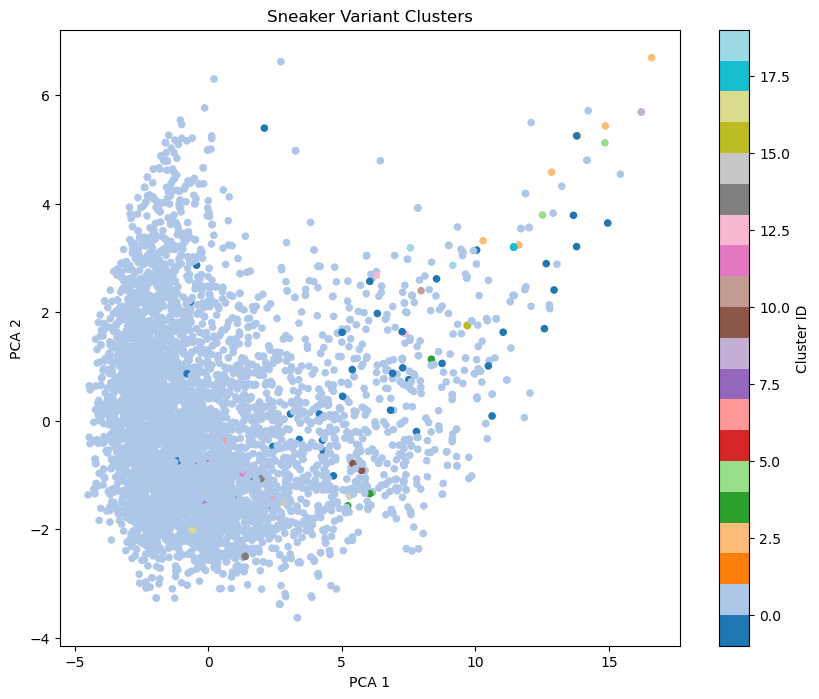

In [70]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce similarity to distance
distance_matrix = 1 - combined_sim

# Use PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(distance_matrix)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_filtered['variant_group'], cmap='tab20', s=20)
plt.title("Sneaker Variant Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster ID")
plt.show()


In [71]:
from collections import defaultdict

# Merge merchant info
merchant_map = df_sources.set_index("mirakl_product_id")["provider_code"].to_dict()

# Cleaned JSON
variant_groups = {}
for group_id in df_filtered["variant_group"].unique():
    if group_id == -1:
        continue  # skip noise
    group = df_filtered[df_filtered["variant_group"] == group_id]
    first = group.iloc[0]
    group_json = {
        "model_name": first["product_name"],
        "brand": first["brand"],
        "variants": [],
        "offers": []
    }
    seen = set()
    for _, row in group.iterrows():
        variant_key = (row["color"], row["size"])
        if variant_key not in seen:
            seen.add(variant_key)
            group_json["variants"].append({
                "color": row["color"],
                "size": row["size"],
                "image": row.get("mainImage.original_url", ""),
                "product_group_id": row["product_group_id"]
            })
        group_json["offers"].append({
            "merchant": merchant_map.get(row["product_group_id"], "unknown"),
            "product_sku": row.get("product_sku", ""),
            "product_group_id": row["product_group_id"]
        })
    variant_groups[str(group_id)] = group_json

# Save result
with open("variant_groups_cleaned.json", "w") as f:
    json.dump(variant_groups, f, indent=2)


In [76]:
with open("variant_groups.json", "r") as f:
    data = json.load(f)

# Preview the first group
first_key = list(data.keys())[0]
print(json.dumps(data[first_key], indent=2))


{
  "model_name": "Gel-rocket 11 mens volleyball/indoor shoes",
  "brand": "ASICS",
  "variants": [
    {
      "color": "White / Black",
      "size": "44",
      "image": "https://administrator.athlokinisi.com.cy/product_catalog/groups/162995/1071a091-101.jpg",
      "product_group_id": 1041.0
    },
    {
      "color": "Black",
      "size": "44",
      "image": "https://privesports.com.cy/product_catalog/groups/66610/vn0a3mtjt2j1-black.jpg",
      "product_group_id": 4423.0
    },
    {
      "color": NaN,
      "size": "44.5",
      "image": "https://jinius-prod.mirakl.net/mmp/media/product-media/34383/IH6003-1.jpg",
      "product_group_id": NaN
    },
    {
      "color": "White / Black / Volt",
      "size": "42",
      "image": "https://administrator.athlokinisi.com.cy/product_catalog/groups/164557/ct2927-100.jpg",
      "product_group_id": 2839.0
    },
    {
      "color": "Black/white",
      "size": "11/EU 46",
      "image": "https://s3.gy.digital/famousports/uploads/ass

In [ ]:
### provider unknown for some reason